In [2]:
from pathlib import Path
from typing import Optional
import csv

import numpy as np
from PIL import Image


def analyze_masks(dir_path: str, out_csv: Optional[str] = None) -> None:
    """
    Scan `dir_path` for images, treat non-zero pixels as positive,
    and print + optionally save per-file counts and proportions.

    Args:
        dir_path: Directory containing binary masks (zeros and ones).
        out_csv: Optional path to write CSV with columns:
                 filename,positive_count,negative_count,positive_fraction
    """
    p = Path(dir_path)
    files = sorted([f for f in p.iterdir() if f.is_file()])
    rows = []
    total_pos = 0
    total_pixels = 0

    for f in files:
        im = Image.open(f).convert("L")
        arr = np.asarray(im)
        pos = int((arr > 0).sum())
        tot = int(arr.size)
        neg = tot - pos
        frac = pos / tot if tot > 0 else 0.0
        rows.append((str(f.name), pos, neg, frac))
        total_pos += pos
        total_pixels += tot
        print(f"{f.name}: pos={pos}, neg={neg}, pos_frac={frac:.6f}")

    print(
        f"Summary: files={len(rows)}, total_pos={total_pos}, total_pixels={total_pixels}, overall_pos_frac={total_pos / total_pixels:.6f}"
    )

    if out_csv:
        with open(out_csv, "w", newline="") as fh:
            writer = csv.writer(fh)
            writer.writerow(
                ["filename", "positive_count", "negative_count", "positive_fraction"]
            )
            for r in rows:
                writer.writerow(r)
        print(f"Wrote CSV: {out_csv}")


binary_mask_dir = "../eval_old/"
output_dir = "../eval_old/stats.csv"
analyze_masks(binary_mask_dir, output_dir)

44984.png: pos=7637, neg=24992363, pos_frac=0.000305
51782.png: pos=14821, neg=24985179, pos_frac=0.000593
51792.png: pos=10347, neg=24989653, pos_frac=0.000414
51793.png: pos=3236, neg=24996764, pos_frac=0.000129
52613.png: pos=16720, neg=24983280, pos_frac=0.000669
52721.png: pos=16057, neg=24983943, pos_frac=0.000642
52722.png: pos=12970, neg=24987030, pos_frac=0.000519
52741.png: pos=11007, neg=24988993, pos_frac=0.000440
52743.png: pos=10483, neg=24989517, pos_frac=0.000419
52744.png: pos=423, neg=24999577, pos_frac=0.000017
52803.png: pos=7051, neg=24992949, pos_frac=0.000282
52814.png: pos=1406, neg=24998594, pos_frac=0.000056
52843.png: pos=15836, neg=24984164, pos_frac=0.000633
52883.png: pos=9, neg=24999991, pos_frac=0.000000
52951.png: pos=12742, neg=24987258, pos_frac=0.000510
52953.png: pos=4271, neg=24995729, pos_frac=0.000171
52983.png: pos=7518, neg=24992482, pos_frac=0.000301
53691.png: pos=14088, neg=24985912, pos_frac=0.000564
53693.png: pos=9717, neg=24990283, pos_f

In [4]:
import pandas as pd

stats_df = pd.read_csv("../eval_old/stats.csv")

display(stats_df)

,filename,positive_count,negative_count,positive_fraction
0,44984.png,7637,24992363,0.000305
1,51782.png,14821,24985179,0.000593
2,51792.png,10347,24989653,0.000414
3,51793.png,3236,24996764,0.000129
4,52613.png,16720,24983280,0.000669
...,...,...,...,...
113,64953.png,9495,24990505,0.000380
114,64962.png,10440,24989560,0.000418
115,64981.png,8641,24991359,0.000346
116,65834.png,1734,24998266,0.000069


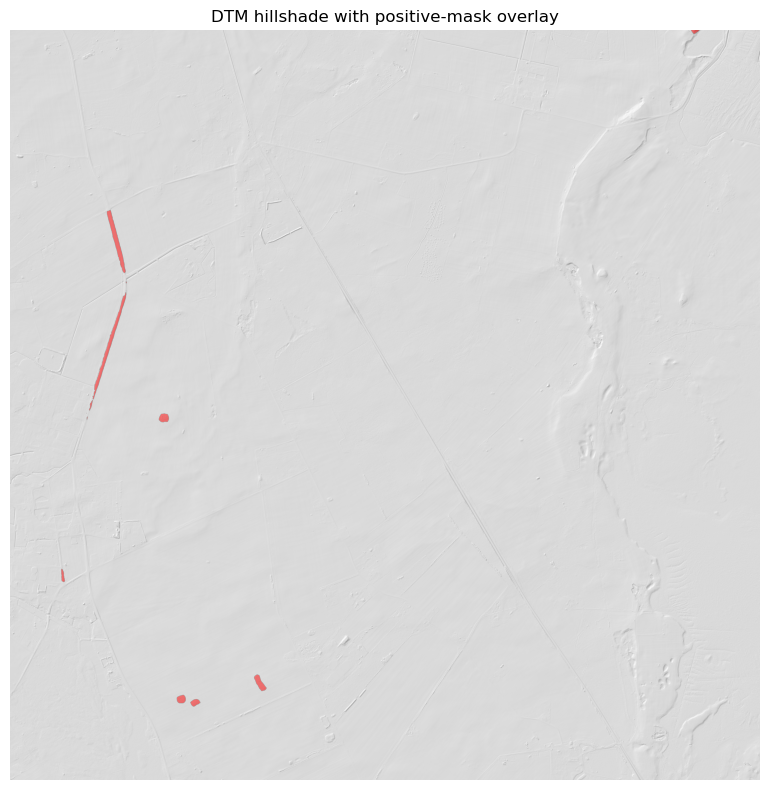

In [6]:
from pathlib import Path
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

try:
    import rasterio
except Exception:
    rasterio = None


def hillshade(
    array: np.ndarray, azimuth: int = 315, angle_altitude: int = 45
) -> np.ndarray:
    """
    Computes hillshade from a 2D array of elevation data.

    Returns a 2D array scaled 0..255 (dtype=float).
    """
    x, y = np.gradient(array.astype(float))
    slope = np.pi / 2.0 - np.arctan(np.sqrt(x * x + y * y))
    aspect = np.arctan2(-x, y)
    azimuth_rad = azimuth * np.pi / 180.0
    altitude_rad = angle_altitude * np.pi / 180.0
    shaded = np.sin(altitude_rad) * np.sin(slope) + np.cos(altitude_rad) * np.cos(
        slope
    ) * np.cos(azimuth_rad - aspect)
    return 255.0 * (shaded + 1.0) / 2.0


def find_matching_dtm(mask_path: Path, dtm_dir: Path) -> Optional[Path]:
    stem = mask_path.stem
    for ext in (".tif", ".tiff", ".png", ".npy"):
        cand = dtm_dir / (stem + ext)
        if cand.exists():
            return cand
    for f in dtm_dir.rglob("*"):
        if f.is_file() and stem in f.name:
            return f
    return None


def load_mask(mask_path: Path) -> np.ndarray:
    im = Image.open(mask_path).convert("L")
    arr = np.asarray(im)
    return arr > 0


def load_dtm(dtm_path: Path) -> np.ndarray:
    if rasterio and dtm_path.suffix.lower() in (".tif", ".tiff"):
        with rasterio.open(dtm_path) as src:
            dtm = src.read(1).astype(float)
    else:
        dtm = np.asarray(Image.open(dtm_path).convert("F"))
    return dtm


def plot_hillshade_overlay(
    dtm: np.ndarray,
    mask: np.ndarray,
    alpha: float = 0.5,
    azimuth: int = 315,
    altitude: int = 45,
) -> None:
    # compute hillshade
    hs = hillshade(dtm, azimuth=azimuth, angle_altitude=altitude)

    # resize mask if needed (nearest neighbour)
    if mask.shape != dtm.shape:
        try:
            from skimage.transform import resize

            mask_resized = resize(
                mask.astype(float), dtm.shape, order=0, preserve_range=True
            )
            mask = mask_resized >= 0.5
        except Exception:
            # fall back to simple nearest sampling
            yy = np.linspace(0, mask.shape[0] - 1, dtm.shape[0]).round().astype(int)
            xx = np.linspace(0, mask.shape[1] - 1, dtm.shape[1]).round().astype(int)
            mask = mask[np.ix_(yy, xx)]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(hs, cmap="gray", vmin=0, vmax=255)
    ax.set_title("DTM hillshade with positive-mask overlay")
    ax.axis("off")

    overlay = np.zeros((dtm.shape[0], dtm.shape[1], 4), dtype=float)
    overlay[mask, 0] = 1.0
    overlay[mask, 3] = alpha

    ax.imshow(overlay)
    plt.tight_layout()
    plt.show()


binary_mask_image_path = Path("../eval_old/63351.png")
dtm_dir = Path("../data/dtm/")
overlay_alpha = 0.5
azimuth = 315
altitude = 45

dtm_p = find_matching_dtm(binary_mask_image_path, dtm_dir)
if dtm_p is None:
    raise SystemExit(
        f"No matching DTM found in {dtm_dir} for mask {binary_mask_image_path}"
    )

mask = load_mask(binary_mask_image_path)
dtm = load_dtm(dtm_p)
plot_hillshade_overlay(dtm, mask, overlay_alpha, azimuth, altitude)